In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Write the image name here
imgFile = 'kid1.jpg'

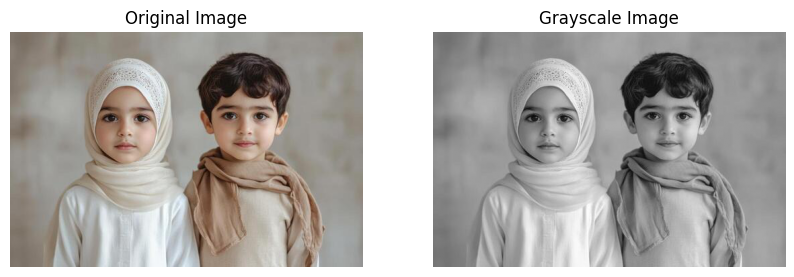

In [2]:
# Load the image
img = cv2.imread(imgFile)

# Check if image loaded correctly
if img is None:
    raise FileNotFoundError("Image not found. Make sure kid1.jpg is in the same folder as this notebook.")

# Convert BGR to RGB for correct display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

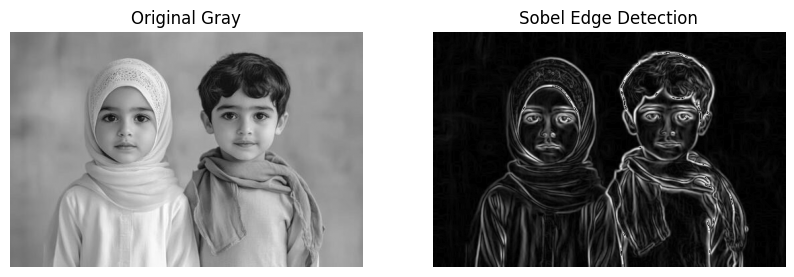

In [3]:
# Apply Gaussian Blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Sobel filter in X and Y directions
sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

# Combine X and Y gradients
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

# Convert to uint8 for display
sobel_final = np.uint8(np.absolute(sobel_combined))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sobel_final, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.show()

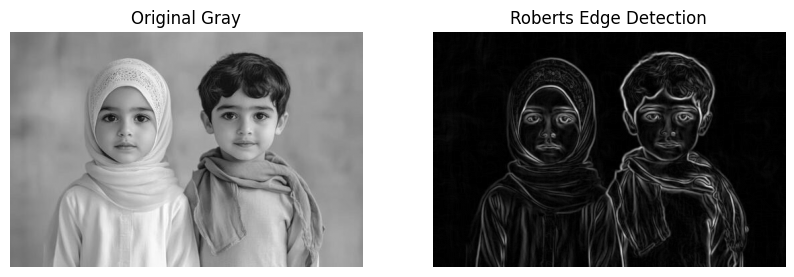

In [4]:
# Apply Gaussian Blur because Roberts is sensitive to noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Roberts kernels
kernel_x = np.array([[1, 0],
                     [0, -1]], dtype=np.float64)

kernel_y = np.array([[0, 1],
                     [-1, 0]], dtype=np.float64)

# Apply Roberts filters
roberts_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
roberts_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)

# Combine X and Y gradients
roberts_combined = cv2.magnitude(roberts_x, roberts_y)

# Convert to uint8
roberts_final = np.uint8(np.absolute(roberts_combined))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(roberts_final, cmap="gray")
plt.title("Roberts Edge Detection")
plt.axis("off")

plt.show()

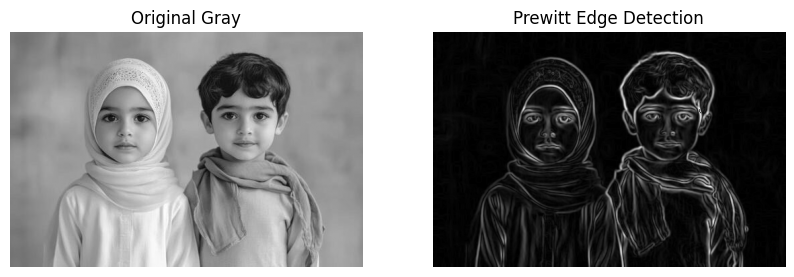

In [5]:
# Apply Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Prewitt kernels
kernel_x = np.array([[-1, 0, 1],
                     [-1, 0, 1],
                     [-1, 0, 1]], dtype=np.float64)

kernel_y = np.array([[-1, -1, -1],
                     [0, 0, 0],
                     [1, 1, 1]], dtype=np.float64)

# Apply Prewitt filters
prewitt_x = cv2.filter2D(blurred, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(blurred, cv2.CV_64F, kernel_y)

# Combine X and Y gradients
prewitt_combined = cv2.magnitude(prewitt_x, prewitt_y)

# Convert to uint8
prewitt_final = np.uint8(np.absolute(prewitt_combined))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(prewitt_final, cmap="gray")
plt.title("Prewitt Edge Detection")
plt.axis("off")

plt.show()

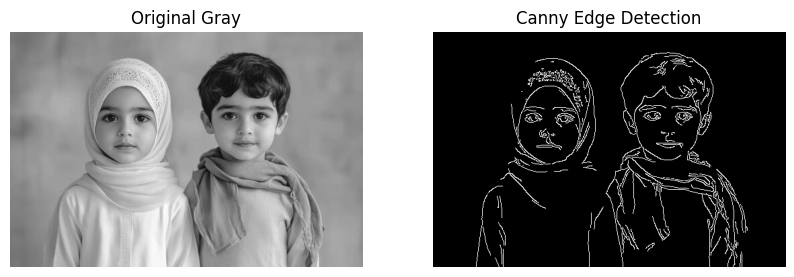

In [6]:
# Apply Canny Edge Detection
canny_edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(canny_edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

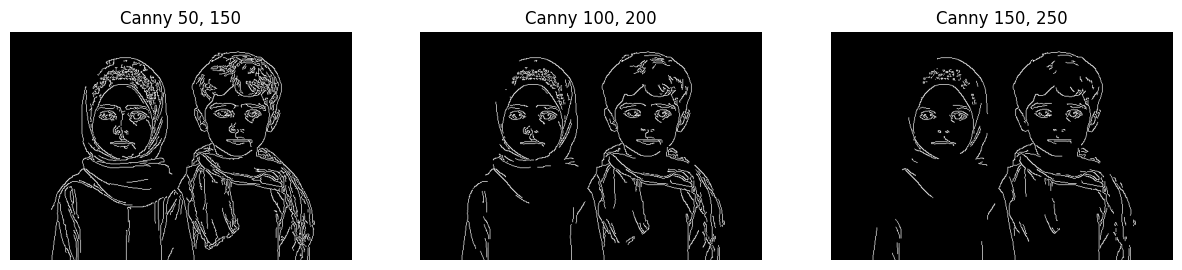

In [7]:
# Try different threshold values
canny_50_150 = cv2.Canny(gray, 50, 150)
canny_100_200 = cv2.Canny(gray, 100, 200)
canny_150_250 = cv2.Canny(gray, 150, 250)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(canny_50_150, cmap="gray")
plt.title("Canny 50, 150")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(canny_100_200, cmap="gray")
plt.title("Canny 100, 200")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_150_250, cmap="gray")
plt.title("Canny 150, 250")
plt.axis("off")

plt.show()

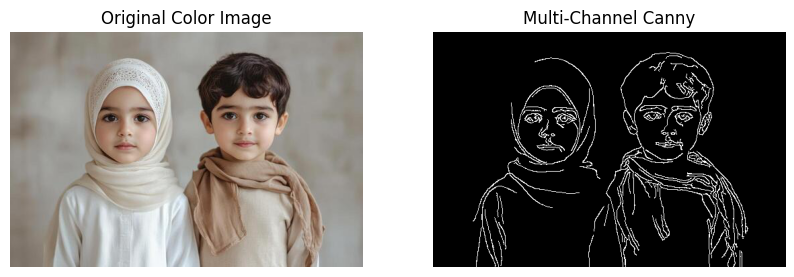

In [8]:
# Split image into B, G, R channels
b, g, r = cv2.split(img)

edge_maps = []

# Apply Canny on each channel
for channel in [b, g, r]:
    blurred_channel = cv2.GaussianBlur(channel, (5, 5), 0)
    edges = cv2.Canny(blurred_channel, 50, 150)
    edge_maps.append(edges)

# Combine edges from all channels
multi_channel_edges = np.maximum.reduce(edge_maps)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(multi_channel_edges, cmap="gray")
plt.title("Multi-Channel Canny")
plt.axis("off")

plt.show()

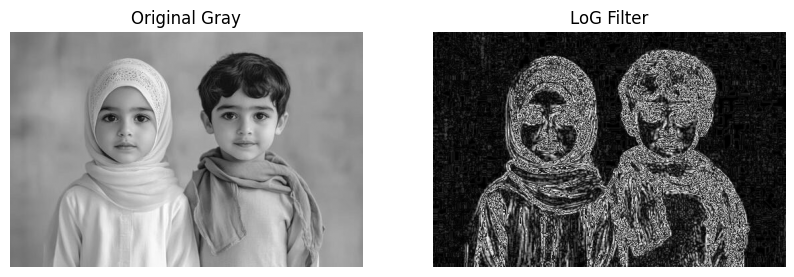

In [9]:
# Apply Gaussian Blur
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Laplacian filter
laplacian = cv2.Laplacian(blurred, cv2.CV_64F, ksize=5)

# Convert to uint8
log_final = np.uint8(np.absolute(laplacian))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_final, cmap="gray")
plt.title("LoG Filter")
plt.axis("off")

plt.show()

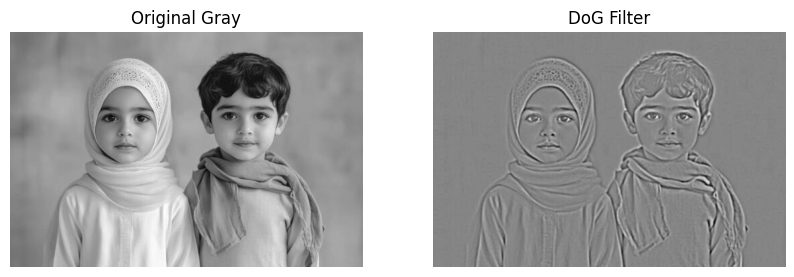

In [10]:
# Apply two Gaussian blurs with different sigma values
blur_narrow = cv2.GaussianBlur(gray, (0, 0), sigmaX=1.0)
blur_wide = cv2.GaussianBlur(gray, (0, 0), sigmaX=2.0)

# Difference of Gaussian
dog = blur_narrow.astype(np.float32) - blur_wide.astype(np.float32)

# Normalize result for display
dog_normalized = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX)
dog_final = dog_normalized.astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dog_final, cmap="gray")
plt.title("DoG Filter")
plt.axis("off")

plt.show()

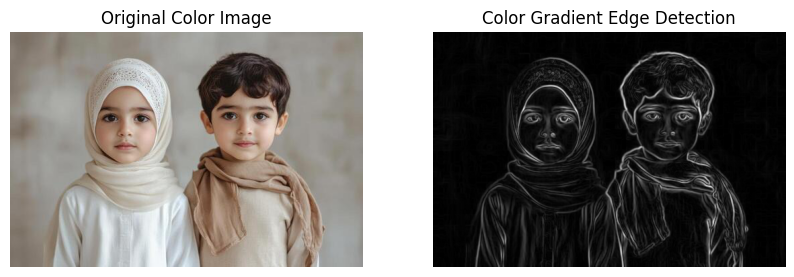

In [11]:
# Split image into color channels
b, g, r = cv2.split(img)

def get_channel_gradient(channel):
    # Blur the channel to reduce noise
    blurred = cv2.GaussianBlur(channel, (3, 3), 0)
    
    # Compute Sobel gradients
    gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    
    # Compute gradient magnitude
    magnitude = cv2.magnitude(gx, gy)
    
    return magnitude

# Compute gradient for each channel
grad_b = get_channel_gradient(b)
grad_g = get_channel_gradient(g)
grad_r = get_channel_gradient(r)

# Combine all channel gradients
combined_gradient = np.sqrt(grad_b**2 + grad_g**2 + grad_r**2)

# Normalize to 0-255
color_edges = cv2.normalize(combined_gradient, None, 0, 255, cv2.NORM_MINMAX)
color_edges = color_edges.astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(color_edges, cmap="gray")
plt.title("Color Gradient Edge Detection")
plt.axis("off")

plt.show()

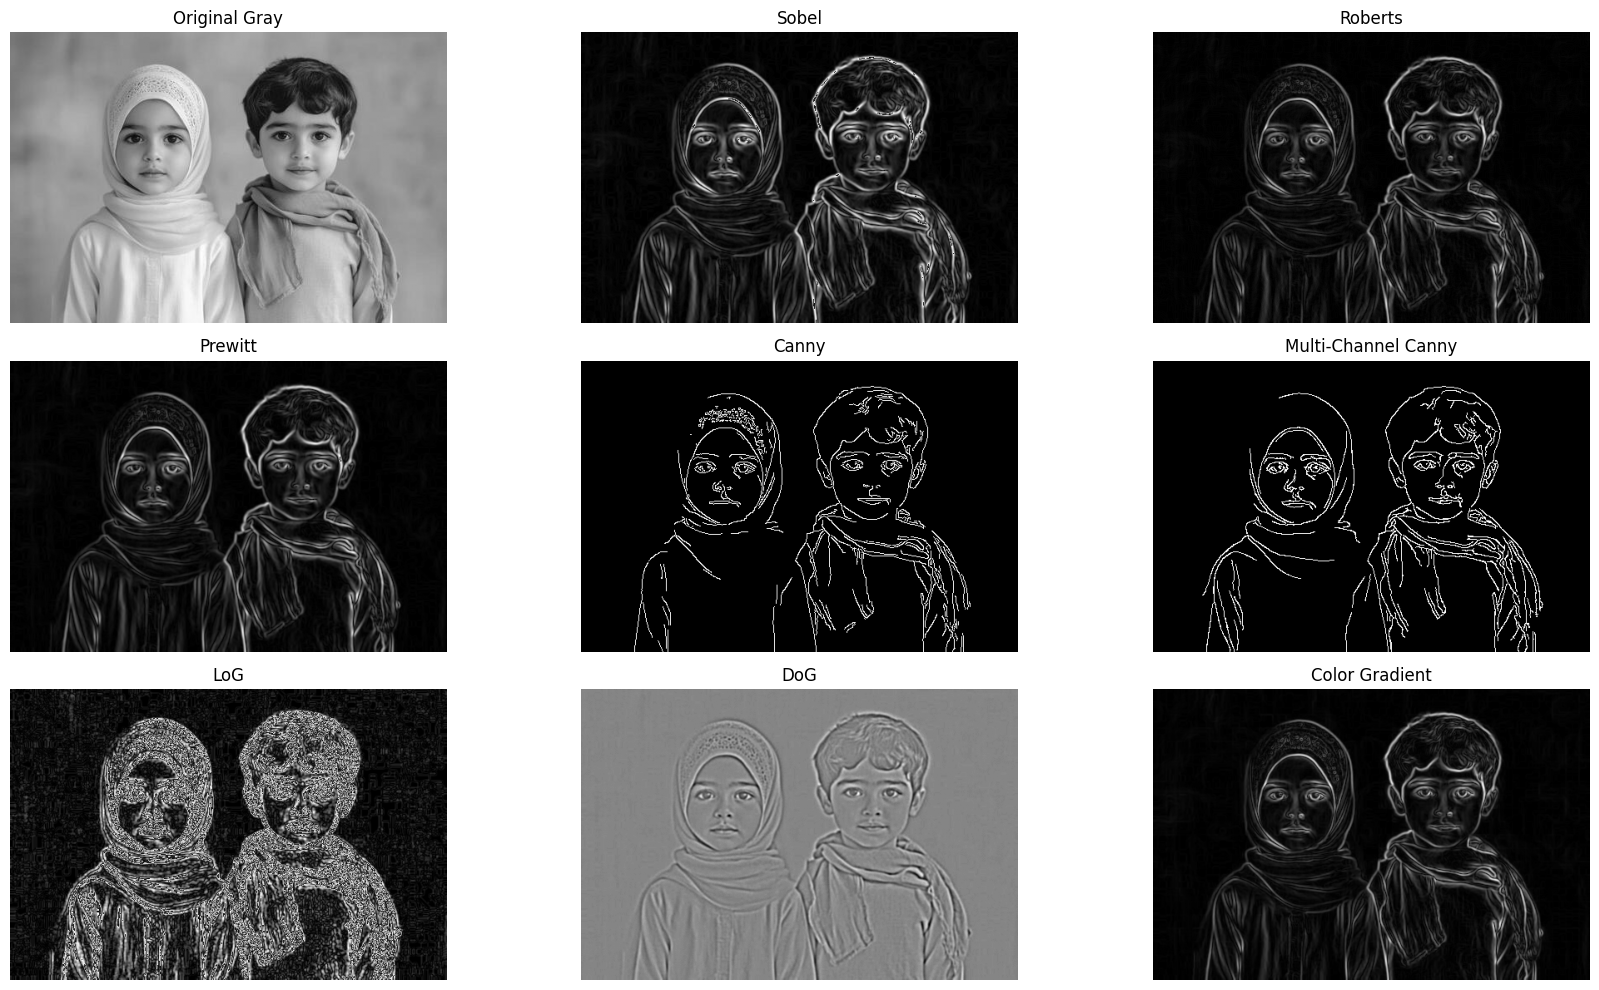

In [12]:
plt.figure(figsize=(18, 10))

results = [
    ("Original Gray", gray),
    ("Sobel", sobel_final),
    ("Roberts", roberts_final),
    ("Prewitt", prewitt_final),
    ("Canny", canny_edges),
    ("Multi-Channel Canny", multi_channel_edges),
    ("LoG", log_final),
    ("DoG", dog_final),
    ("Color Gradient", color_edges)
]

for i, (title, image) in enumerate(results):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
print("Conclusion:")
print("Sobel gives strong and smooth edges.")
print("Roberts gives thin edges but is very sensitive to noise.")
print("Prewitt is similar to Sobel but usually less smooth.")
print("Canny gives the cleanest and most accurate edge map.")
print("Multi-channel Canny can detect color-based edges that grayscale may miss.")
print("LoG uses Gaussian smoothing followed by the Laplacian second derivative.")
print("DoG approximates LoG by subtracting two blurred images.")

Conclusion:
Sobel gives strong and smooth edges.
Roberts gives thin edges but is very sensitive to noise.
Prewitt is similar to Sobel but usually less smooth.
Canny gives the cleanest and most accurate edge map.
Multi-channel Canny can detect color-based edges that grayscale may miss.
LoG uses Gaussian smoothing followed by the Laplacian second derivative.
DoG approximates LoG by subtracting two blurred images.
